Cell 1 — Import Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Cell 2 — Load Datasets

In [80]:
suppliers = pd.read_csv("../data/cleaned/suppliers.csv")
purchase_header = pd.read_csv("../data/cleaned/purchase_header.csv")
purchase_lines = pd.read_csv("../data/cleaned/purchase_lines.csv")
products = pd.read_csv("../data/cleaned/products.csv")

Cell 3 — Check the Data

In [81]:
print("Suppliers:")
print(suppliers.shape)

print("\nPurchase Header:")
print(purchase_header.shape)

print("\nPurchase Lines:")
print(purchase_lines.shape)

print("\nProducts:")
print(products.shape)

Suppliers:
(8, 12)

Purchase Header:
(24000, 16)

Purchase Lines:
(155495, 9)

Products:
(30, 25)


Cell 4 — Display Columns

In [82]:
print("SUPPLIERS")
print(suppliers.columns.tolist())

print("\nPURCHASE HEADER")
print(purchase_header.columns.tolist())

print("\nPURCHASE LINES")
print(purchase_lines.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

SUPPLIERS
['supplier_id', 'supplier_name', 'supplier_type', 'product_category', 'city', 'province', 'region', 'pincode', 'lead_time_days', 'reliability_score', 'import_duty_rate', 'china_tax_id']

PURCHASE HEADER
['po_id', 'supplier_id', 'branch_id', 'order_date', 'expected_delivery_date', 'received_date', 'po_status', 'total_cost', 'total_gst_amount', 'grand_total', 'order_date_year', 'order_date_month', 'expected_delivery_date_year', 'expected_delivery_date_month', 'received_date_year', 'received_date_month']

PURCHASE LINES
['po_id', 'line_number', 'product_id', 'quantity', 'unit_cost', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total']

PRODUCTS
['product_id', 'product_name', 'category', 'machine_type', 'brand', 'model_compatibility', 'unit_cost', 'unit_price', 'margin_percentage', 'gst_rate', 'weight_kg', 'dimensions_cm', 'material_type', 'warranty_months', 'reorder_level', 'safety_stock', 'max_stock_level', 'lead_time_days', 'criticality_level', 'usage_frequency', 'uom',

Cell 5 — Supplier Summary

In [83]:
supplier_summary = suppliers[[
    "supplier_id",
    "supplier_name",
    "supplier_type",
    "product_category",
    "region",
    "lead_time_days",
    "reliability_score"
]]

supplier_summary.head(10)

,supplier_id,supplier_name,supplier_type,product_category,region,lead_time_days,reliability_score
0,Sup0001,Shenzhen Oem Supplies,Oem,Medium Parts,South China,19,5
1,Sup0002,Guangzhou Local Vendor Supplies,Local Vendor,Small Parts,South China,10,5
2,Sup0003,Shanghai Distributor Supplies,Distributor,Large Parts,East China,16,4
3,Sup0004,Ningbo Distributor Supplies,Distributor,Large Parts,East China,18,3
4,Sup0005,Tianjin Oem Supplies,Oem,Small Parts,North China,28,3
5,Sup0006,Qingdao Distributor Supplies,Distributor,Large Parts,East China,10,3
6,Sup0007,Suzhou Local Vendor Supplies,Local Vendor,Medium Parts,East China,12,5
7,Sup0008,Hangzhou Oem Supplies,Oem,Small Parts,East China,26,4


Cell 6 — Calculate Procurement Value

In [84]:
procurement_value = purchase_lines.groupby(
    "po_id"
)["line_grand_total"].sum().reset_index()

procurement_value.rename(
    columns={"line_grand_total": "procurement_value"},
    inplace=True
)

procurement_value.head()

,po_id,procurement_value
0,Po-100001,1.528608e+07
1,Po-100003,1.653476e+07
2,Po-100013,3.492240e+06
3,Po-100032,1.721058e+06
4,Po-100130,6.379219e+05


Cell 7 — Merge Purchase Header

In [85]:
purchase_data = purchase_header.merge(
    procurement_value,
    on="po_id",
    how="left"
)

purchase_data.head()

,po_id,supplier_id,branch_id,order_date,expected_delivery_date,received_date,po_status,total_cost,total_gst_amount,grand_total,order_date_year,order_date_month,expected_delivery_date_year,expected_delivery_date_month,received_date_year,received_date_month,procurement_value
0,Po-141186,Sup0001,Pun001,2019-04-10,2019-04-29,2019-04-29,Received,22955232.11,6.427465e+06,2.938270e+07,2019,4,2019,4,2019.0,4.0,2.938270e+07
1,Po-215234,Sup0005,Del001,2020-12-30,2021-01-27,2021-01-27,Received,19406544.39,5.428358e+06,2.483490e+07,2020,12,2021,1,2021.0,1.0,2.483490e+07
2,Po-296826,Sup0008,Ahm001,2022-04-05,2022-05-01,2022-05-01,Received,1295425.79,3.627192e+05,1.658145e+06,2022,4,2022,5,2022.0,5.0,1.658145e+06
3,Po-700652,Sup0004,Ahm001,2019-07-29,2019-08-16,2019-08-17,Received,38753295.34,1.080312e+07,4.955641e+07,2019,7,2019,8,2019.0,8.0,4.955641e+07
4,Po-120358,Sup0004,Del001,2024-05-14,2024-06-01,2024-06-01,Received,614701.45,1.106463e+05,7.253477e+05,2024,5,2024,6,2024.0,6.0,7.253477e+05


Cell 8 — Merge Supplier Information

In [86]:
purchase_data = purchase_data.merge(
    suppliers,
    on="supplier_id",
    how="left"
)

purchase_data.head()

,po_id,supplier_id,branch_id,order_date,expected_delivery_date,received_date,po_status,total_cost,total_gst_amount,grand_total,order_date_year,order_date_month,expected_delivery_date_year,expected_delivery_date_month,received_date_year,received_date_month,procurement_value,supplier_name,supplier_type,product_category,city,province,region,pincode,lead_time_days,reliability_score,import_duty_rate,china_tax_id
0,Po-141186,Sup0001,Pun001,2019-04-10,2019-04-29,2019-04-29,Received,22955232.11,6.427465e+06,2.938270e+07,2019,4,2019,4,2019.0,4.0,2.938270e+07,Shenzhen Oem Supplies,Oem,Medium Parts,Shenzhen,Guangdong,South China,586808,19,5,8,90Suzhou398241
1,Po-215234,Sup0005,Del001,2020-12-30,2021-01-27,2021-01-27,Received,19406544.39,5.428358e+06,2.483490e+07,2020,12,2021,1,2021.0,1.0,2.483490e+07,Tianjin Oem Supplies,Oem,Small Parts,Tianjin,Tianjin,North China,334261,28,3,5,59Guangz986793
2,Po-296826,Sup0008,Ahm001,2022-04-05,2022-05-01,2022-05-01,Received,1295425.79,3.627192e+05,1.658145e+06,2022,4,2022,5,2022.0,5.0,1.658145e+06,Hangzhou Oem Supplies,Oem,Small Parts,Hangzhou,Zhejiang,East China,306032,26,4,5,60Qingda640679
3,Po-700652,Sup0004,Ahm001,2019-07-29,2019-08-16,2019-08-17,Received,38753295.34,1.080312e+07,4.955641e+07,2019,7,2019,8,2019.0,8.0,4.955641e+07,Ningbo Distributor Supplies,Distributor,Large Parts,Ningbo,Zhejiang,East China,536477,18,3,8,39Guangz946640
4,Po-120358,Sup0004,Del001,2024-05-14,2024-06-01,2024-06-01,Received,614701.45,1.106463e+05,7.253477e+05,2024,5,2024,6,2024.0,6.0,7.253477e+05,Ningbo Distributor Supplies,Distributor,Large Parts,Ningbo,Zhejiang,East China,536477,18,3,8,39Guangz946640


Cell 9 — Supplier Procurement Value

In [87]:
supplier_procurement = purchase_data.groupby(
    ["supplier_id", "supplier_name"]
).agg(
    Total_Procurement_Value=("procurement_value", "sum"),
    Purchase_Orders=("po_id", "nunique")
).reset_index()

supplier_procurement = supplier_procurement.sort_values(
    "Total_Procurement_Value",
    ascending=False
)

supplier_procurement.head(10)

,supplier_id,supplier_name,Total_Procurement_Value,Purchase_Orders
4,Sup0005,Tianjin Oem Supplies,5.702122e+10,3044
0,Sup0001,Shenzhen Oem Supplies,5.564297e+10,2944
2,Sup0003,Shanghai Distributor Supplies,5.563977e+10,3033
6,Sup0007,Suzhou Local Vendor Supplies,5.559772e+10,3028
7,Sup0008,Hangzhou Oem Supplies,5.535490e+10,3010
5,Sup0006,Qingdao Distributor Supplies,5.509357e+10,3038
3,Sup0004,Ningbo Distributor Supplies,5.406021e+10,2966
1,Sup0002,Guangzhou Local Vendor Supplies,5.327595e+10,2937


Cell 10 — Procurement Value by Supplier

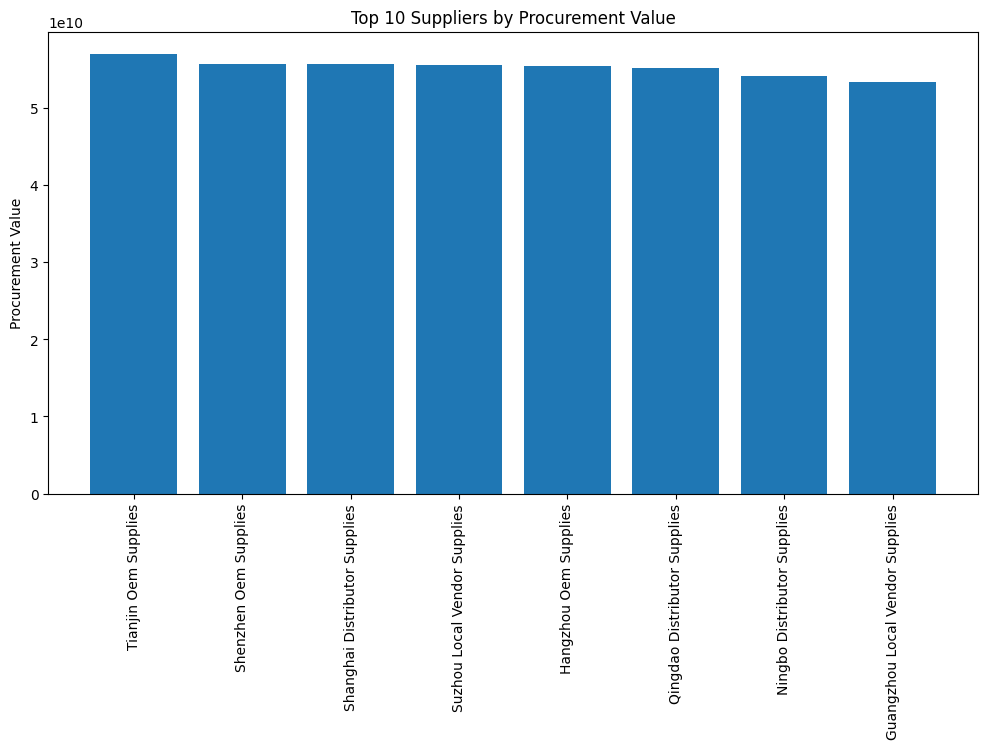

In [88]:
plt.figure(figsize=(12, 6))

plt.bar(
    supplier_procurement.head(10)["supplier_name"],
    supplier_procurement.head(10)["Total_Procurement_Value"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Suppliers by Procurement Value")
plt.ylabel("Procurement Value")

plt.show()

Cell 11 — Purchase Orders by Supplier

In [89]:
orders_by_supplier = purchase_data.groupby(
    "supplier_name"
)["po_id"].nunique().sort_values(
    ascending=False
)

orders_by_supplier.head(10)

supplier_name
Tianjin Oem Supplies               3044
Qingdao Distributor Supplies       3038
Shanghai Distributor Supplies      3033
Suzhou Local Vendor Supplies       3028
Hangzhou Oem Supplies              3010
Ningbo Distributor Supplies        2966
Shenzhen Oem Supplies              2944
Guangzhou Local Vendor Supplies    2937
Name: po_id, dtype: int64

Cell 12 — Purchase Order Status

In [90]:
po_status = purchase_data["po_status"].value_counts()

po_status

po_status
Received     21630
Cancelled     2370
Name: count, dtype: int64

Cell 13 — Purchase Order Status Chart

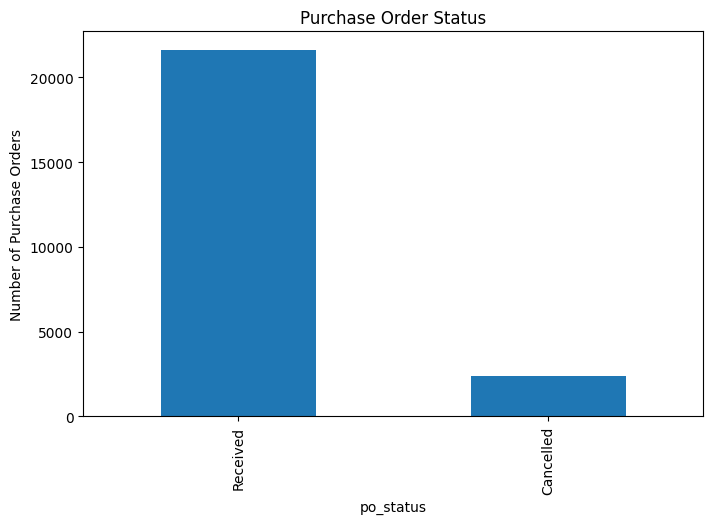

In [91]:
plt.figure(figsize=(8, 5))

po_status.plot(kind="bar")

plt.title("Purchase Order Status")
plt.ylabel("Number of Purchase Orders")

plt.show()

Cell 14 — Supplier Reliability

In [92]:
supplier_reliability = suppliers[[
    "supplier_id",
    "supplier_name",
    "lead_time_days",
    "reliability_score"
]].sort_values(
    "reliability_score",
    ascending=False
)

supplier_reliability.head(10)

,supplier_id,supplier_name,lead_time_days,reliability_score
0,Sup0001,Shenzhen Oem Supplies,19,5
1,Sup0002,Guangzhou Local Vendor Supplies,10,5
6,Sup0007,Suzhou Local Vendor Supplies,12,5
2,Sup0003,Shanghai Distributor Supplies,16,4
7,Sup0008,Hangzhou Oem Supplies,26,4
3,Sup0004,Ningbo Distributor Supplies,18,3
5,Sup0006,Qingdao Distributor Supplies,10,3
4,Sup0005,Tianjin Oem Supplies,28,3


Cell 15 — Supplier Reliability Chart

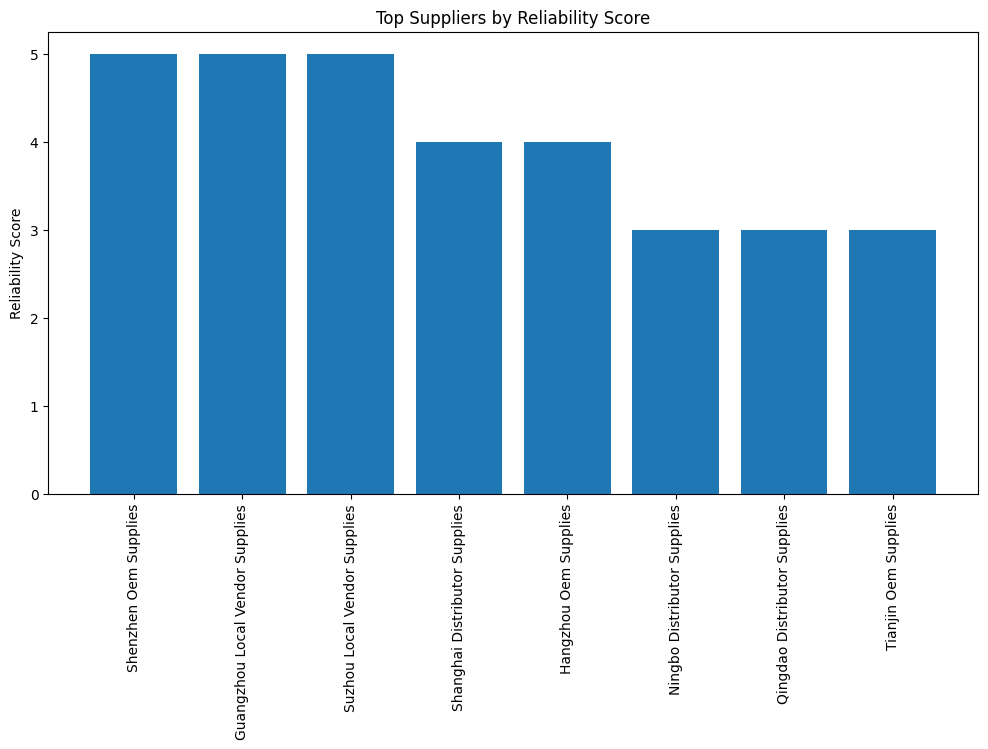

In [93]:
top_reliable = supplier_reliability.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_reliable["supplier_name"],
    top_reliable["reliability_score"]
)

plt.xticks(rotation=90)

plt.title("Top Suppliers by Reliability Score")
plt.ylabel("Reliability Score")

plt.show()

Cell 16 — Average Purchase Order Value

In [94]:
supplier_avg_order = purchase_data.groupby(
    "supplier_name"
)["procurement_value"].mean().sort_values(
    ascending=False
)

supplier_avg_order.head(10)

supplier_name
Shenzhen Oem Supplies              1.890046e+07
Tianjin Oem Supplies               1.873233e+07
Hangzhou Oem Supplies              1.839033e+07
Suzhou Local Vendor Supplies       1.836120e+07
Shanghai Distributor Supplies      1.834480e+07
Ningbo Distributor Supplies        1.822664e+07
Guangzhou Local Vendor Supplies    1.813958e+07
Qingdao Distributor Supplies       1.813482e+07
Name: procurement_value, dtype: float64

Cell 17 — Supplier Performance Table

In [95]:
supplier_performance = supplier_procurement.merge(
    suppliers[[
        "supplier_id",
        "lead_time_days",
        "reliability_score",
        "supplier_type",
        "product_category",
        "region"
    ]],
    on="supplier_id",
    how="left"
)

supplier_performance.head(10)

,supplier_id,supplier_name,Total_Procurement_Value,Purchase_Orders,lead_time_days,reliability_score,supplier_type,product_category,region
0,Sup0005,Tianjin Oem Supplies,5.702122e+10,3044,28,3,Oem,Small Parts,North China
1,Sup0001,Shenzhen Oem Supplies,5.564297e+10,2944,19,5,Oem,Medium Parts,South China
2,Sup0003,Shanghai Distributor Supplies,5.563977e+10,3033,16,4,Distributor,Large Parts,East China
3,Sup0007,Suzhou Local Vendor Supplies,5.559772e+10,3028,12,5,Local Vendor,Medium Parts,East China
4,Sup0008,Hangzhou Oem Supplies,5.535490e+10,3010,26,4,Oem,Small Parts,East China
5,Sup0006,Qingdao Distributor Supplies,5.509357e+10,3038,10,3,Distributor,Large Parts,East China
6,Sup0004,Ningbo Distributor Supplies,5.406021e+10,2966,18,3,Distributor,Large Parts,East China
7,Sup0002,Guangzhou Local Vendor Supplies,5.327595e+10,2937,10,5,Local Vendor,Small Parts,South China


Cell 18 — Convert Dates

In [96]:
purchase_data["order_date"] = pd.to_datetime(
    purchase_data["order_date"],
    errors="coerce"
)

purchase_data["expected_delivery_date"] = pd.to_datetime(
    purchase_data["expected_delivery_date"],
    errors="coerce"
)

purchase_data["received_date"] = pd.to_datetime(
    purchase_data["received_date"],
    errors="coerce"
)

Cell 19 — Delivery Delay

In [97]:
purchase_data["delivery_delay_days"] = (
    purchase_data["received_date"] -
    purchase_data["expected_delivery_date"]
).dt.days

purchase_data[[
    "po_id",
    "supplier_name",
    "expected_delivery_date",
    "received_date",
    "delivery_delay_days"
]].head(10)

,po_id,supplier_name,expected_delivery_date,received_date,delivery_delay_days
0,Po-141186,Shenzhen Oem Supplies,2019-04-29,2019-04-29,0.0
1,Po-215234,Tianjin Oem Supplies,2021-01-27,2021-01-27,0.0
2,Po-296826,Hangzhou Oem Supplies,2022-05-01,2022-05-01,0.0
3,Po-700652,Ningbo Distributor Supplies,2019-08-16,2019-08-17,1.0
4,Po-120358,Ningbo Distributor Supplies,2024-06-01,2024-06-01,0.0
5,Po-975383,Tianjin Oem Supplies,2021-11-29,2021-11-29,0.0
6,Po-699883,Suzhou Local Vendor Supplies,2019-08-19,2019-08-19,0.0
7,Po-310142,Shanghai Distributor Supplies,2020-03-16,2020-03-16,0.0
8,Po-251676,Hangzhou Oem Supplies,2021-04-26,2021-04-26,0.0
9,Po-299240,Shanghai Distributor Supplies,2024-12-10,2024-12-10,0.0


Cell 20 — On-Time Delivery

In [98]:
purchase_data["delivery_status"] = np.where(
    purchase_data["delivery_delay_days"] <= 0,
    "On Time",
    "Delayed"
)

purchase_data["delivery_status"].value_counts()

delivery_status
On Time    18363
Delayed     5637
Name: count, dtype: int64

Cell 21 — Delivery Status Chart

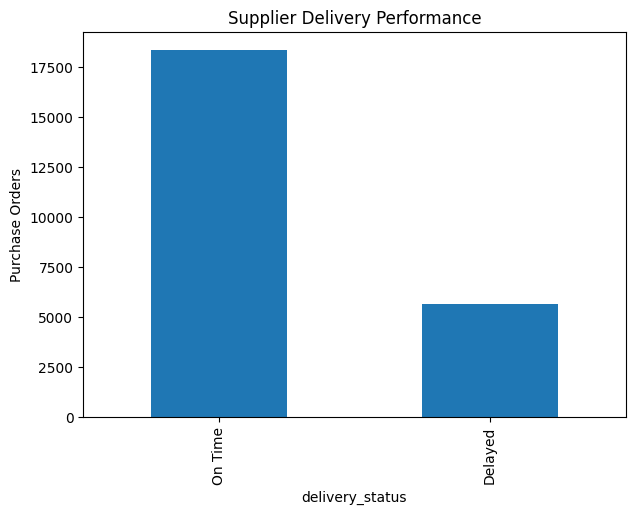

In [99]:
delivery_status = purchase_data[
    "delivery_status"
].value_counts()

plt.figure(figsize=(7, 5))

delivery_status.plot(kind="bar")

plt.title("Supplier Delivery Performance")

plt.ylabel("Purchase Orders")

plt.show()

Cell 22 — Supplier Delivery Performance

In [100]:
supplier_delivery = purchase_data.groupby(
    ["supplier_id", "supplier_name"]
).agg(
    Total_Orders=("po_id", "nunique"),
    Average_Delay_Days=("delivery_delay_days", "mean"),
    On_Time_Orders=("delivery_status", lambda x: (x == "On Time").sum()),
    Delayed_Orders=("delivery_status", lambda x: (x == "Delayed").sum())
).reset_index()

supplier_delivery["On_Time_Rate"] = (
    supplier_delivery["On_Time_Orders"] /
    supplier_delivery["Total_Orders"]
) * 100

supplier_delivery["On_Time_Rate"] = (
    supplier_delivery["On_Time_Rate"].round(2)
)

supplier_delivery.sort_values(
    "On_Time_Rate",
    ascending=False
).head(10)

,supplier_id,supplier_name,Total_Orders,Average_Delay_Days,On_Time_Orders,Delayed_Orders,On_Time_Rate
4,Sup0005,Tianjin Oem Supplies,3044,0.485476,2350,694,77.20
5,Sup0006,Qingdao Distributor Supplies,3038,0.501090,2345,693,77.19
0,Sup0001,Shenzhen Oem Supplies,2944,0.496419,2253,691,76.53
2,Sup0003,Shanghai Distributor Supplies,3033,0.531399,2315,718,76.33
6,Sup0007,Suzhou Local Vendor Supplies,3028,0.528053,2309,719,76.25
1,Sup0002,Guangzhou Local Vendor Supplies,2937,0.516129,2239,698,76.23
3,Sup0004,Ningbo Distributor Supplies,2966,0.497372,2260,706,76.20
7,Sup0008,Hangzhou Oem Supplies,3010,0.545555,2292,718,76.15


Cell 23 — Procurement Share

In [101]:
total_procurement = supplier_procurement[
    "Total_Procurement_Value"
].sum()

supplier_procurement["Procurement_Share_%"] = (
    supplier_procurement["Total_Procurement_Value"] /
    total_procurement
) * 100

supplier_procurement["Procurement_Share_%"] = (
    supplier_procurement["Procurement_Share_%"].round(2)
)

supplier_procurement.head(10)

,supplier_id,supplier_name,Total_Procurement_Value,Purchase_Orders,Procurement_Share_%
4,Sup0005,Tianjin Oem Supplies,5.702122e+10,3044,12.91
0,Sup0001,Shenzhen Oem Supplies,5.564297e+10,2944,12.60
2,Sup0003,Shanghai Distributor Supplies,5.563977e+10,3033,12.60
6,Sup0007,Suzhou Local Vendor Supplies,5.559772e+10,3028,12.59
7,Sup0008,Hangzhou Oem Supplies,5.535490e+10,3010,12.53
5,Sup0006,Qingdao Distributor Supplies,5.509357e+10,3038,12.47
3,Sup0004,Ningbo Distributor Supplies,5.406021e+10,2966,12.24
1,Sup0002,Guangzhou Local Vendor Supplies,5.327595e+10,2937,12.06


Cell 24 — Cumulative Procurement Share

In [102]:
supplier_procurement = supplier_procurement.sort_values(
    "Total_Procurement_Value",
    ascending=False
)

supplier_procurement["Cumulative_Share_%"] = (
    supplier_procurement["Procurement_Share_%"].cumsum()
).round(2)

supplier_procurement.head(10)

,supplier_id,supplier_name,Total_Procurement_Value,Purchase_Orders,Procurement_Share_%,Cumulative_Share_%
4,Sup0005,Tianjin Oem Supplies,5.702122e+10,3044,12.91,12.91
0,Sup0001,Shenzhen Oem Supplies,5.564297e+10,2944,12.60,25.51
2,Sup0003,Shanghai Distributor Supplies,5.563977e+10,3033,12.60,38.11
6,Sup0007,Suzhou Local Vendor Supplies,5.559772e+10,3028,12.59,50.70
7,Sup0008,Hangzhou Oem Supplies,5.535490e+10,3010,12.53,63.23
5,Sup0006,Qingdao Distributor Supplies,5.509357e+10,3038,12.47,75.70
3,Sup0004,Ningbo Distributor Supplies,5.406021e+10,2966,12.24,87.94
1,Sup0002,Guangzhou Local Vendor Supplies,5.327595e+10,2937,12.06,100.00


Cell 25 — Supplier Dependency Classification

In [103]:
supplier_procurement["Dependency_Level"] = np.select(
    [
        supplier_procurement["Procurement_Share_%"] >= 20,
        supplier_procurement["Procurement_Share_%"] >= 10
    ],
    [
        "High Dependency",
        "Medium Dependency"
    ],
    default="Low Dependency"
)

supplier_procurement[[
    "supplier_name",
    "Procurement_Share_%",
    "Dependency_Level"
]].head(15)

,supplier_name,Procurement_Share_%,Dependency_Level
4,Tianjin Oem Supplies,12.91,Medium Dependency
0,Shenzhen Oem Supplies,12.60,Medium Dependency
2,Shanghai Distributor Supplies,12.60,Medium Dependency
6,Suzhou Local Vendor Supplies,12.59,Medium Dependency
7,Hangzhou Oem Supplies,12.53,Medium Dependency
5,Qingdao Distributor Supplies,12.47,Medium Dependency
3,Ningbo Distributor Supplies,12.24,Medium Dependency
1,Guangzhou Local Vendor Supplies,12.06,Medium Dependency


Cell 26 — Merge Purchase Lines with Products

In [104]:
purchase_product = purchase_lines.merge(
    products[[
        "product_id",
        "product_name",
        "category",
        "criticality_level"
    ]],
    on="product_id",
    how="left"
)

purchase_product.head()

,po_id,line_number,product_id,quantity,unit_cost,gst_rate,line_total,gst_amount,line_grand_total,product_name,category,criticality_level
0,Po-141186,1,P004,234,34709.54,28,8122032.36,2.274169e+06,1.039620e+07,Track Chain Tc-45,Undercarriage,High
1,Po-141186,2,P022,79,12317.84,28,973109.36,2.724706e+05,1.245580e+06,Control Valve Cv-75,Hydraulic,High
2,Po-141186,3,P030,46,13840.45,28,636660.70,1.782650e+05,8.149257e+05,Fuel Pump Fp-350,Engine,High
3,Po-141186,4,P001,293,16988.41,28,4977604.13,1.393729e+06,6.371333e+06,Hydraulic Pump Hp-300,Hydraulic,High
4,Po-141186,5,P014,126,65443.06,28,8245825.56,2.308831e+06,1.055466e+07,Transmission Assembly Ta-800,Transmission,High


Cell 27 — Products Purchased from Suppliers

In [105]:
supplier_products = purchase_product.merge(
    purchase_header[[
        "po_id",
        "supplier_id"
    ]],
    on="po_id",
    how="left"
)

supplier_products = supplier_products.merge(
    suppliers[[
        "supplier_id",
        "supplier_name"
    ]],
    on="supplier_id",
    how="left"
)

supplier_products.head()

,po_id,line_number,product_id,quantity,unit_cost,gst_rate,line_total,gst_amount,line_grand_total,product_name,category,criticality_level,supplier_id,supplier_name
0,Po-141186,1,P004,234,34709.54,28,8122032.36,2.274169e+06,1.039620e+07,Track Chain Tc-45,Undercarriage,High,Sup0001,Shenzhen Oem Supplies
1,Po-141186,2,P022,79,12317.84,28,973109.36,2.724706e+05,1.245580e+06,Control Valve Cv-75,Hydraulic,High,Sup0001,Shenzhen Oem Supplies
2,Po-141186,3,P030,46,13840.45,28,636660.70,1.782650e+05,8.149257e+05,Fuel Pump Fp-350,Engine,High,Sup0001,Shenzhen Oem Supplies
3,Po-141186,4,P001,293,16988.41,28,4977604.13,1.393729e+06,6.371333e+06,Hydraulic Pump Hp-300,Hydraulic,High,Sup0001,Shenzhen Oem Supplies
4,Po-141186,5,P014,126,65443.06,28,8245825.56,2.308831e+06,1.055466e+07,Transmission Assembly Ta-800,Transmission,High,Sup0001,Shenzhen Oem Supplies


Cell 28 — Supplier Product Count

In [106]:
supplier_product_count = supplier_products.groupby(
    ["supplier_id", "supplier_name"]
)["product_id"].nunique().reset_index()

supplier_product_count.rename(
    columns={
        "product_id": "Unique_Products_Supplied"
    },
    inplace=True
)

supplier_product_count.sort_values(
    "Unique_Products_Supplied",
    ascending=False
).head(10)

,supplier_id,supplier_name,Unique_Products_Supplied
0,Sup0001,Shenzhen Oem Supplies,30
1,Sup0002,Guangzhou Local Vendor Supplies,30
2,Sup0003,Shanghai Distributor Supplies,30
3,Sup0004,Ningbo Distributor Supplies,30
4,Sup0005,Tianjin Oem Supplies,30
5,Sup0006,Qingdao Distributor Supplies,30
6,Sup0007,Suzhou Local Vendor Supplies,30
7,Sup0008,Hangzhou Oem Supplies,30


Cell 29 — Critical Products by Supplier

In [107]:
critical_supplier_products = supplier_products[
    supplier_products["criticality_level"].str.lower().isin(
        ["high", "critical"]
    )
]

critical_supplier_summary = critical_supplier_products.groupby(
    "supplier_name"
)["product_id"].nunique().sort_values(
    ascending=False
)

critical_supplier_summary.head(10)

supplier_name
Guangzhou Local Vendor Supplies    16
Hangzhou Oem Supplies              16
Ningbo Distributor Supplies        16
Qingdao Distributor Supplies       16
Shanghai Distributor Supplies      16
Shenzhen Oem Supplies              16
Suzhou Local Vendor Supplies       16
Tianjin Oem Supplies               16
Name: product_id, dtype: int64

Cell 30 — Supplier KPI Dashboard

In [108]:
supplier_kpis = pd.DataFrame({

    "KPI": [
        "Total Suppliers",
        "Total Purchase Orders",
        "Total Procurement Value",
        "Average Purchase Order Value",
        "Average Supplier Reliability",
        "Delayed Purchase Orders",
        "On-Time Purchase Orders"
    ],

    "Value": [
        suppliers["supplier_id"].nunique(),

        purchase_data["po_id"].nunique(),

        purchase_data["procurement_value"].sum(),

        purchase_data["procurement_value"].mean(),

        suppliers["reliability_score"].mean(),

        (purchase_data["delivery_status"] == "Delayed").sum(),

        (purchase_data["delivery_status"] == "On Time").sum()
    ]
})

supplier_kpis

,KPI,Value
0,Total Suppliers,8.000000e+00
1,Total Purchase Orders,2.400000e+04
2,Total Procurement Value,4.416863e+11
3,Average Purchase Order Value,1.840360e+07
4,Average Supplier Reliability,4.000000e+00
5,Delayed Purchase Orders,5.637000e+03
6,On-Time Purchase Orders,1.836300e+04


Cell 31 — Business Insights

In [109]:
top_supplier = supplier_procurement.iloc[0]

most_reliable = supplier_reliability.iloc[0]

most_delayed = supplier_delivery.sort_values(
    "Average_Delay_Days",
    ascending=False
).iloc[0]

print("=" * 70)
print("SUPPLIER & PROCUREMENT BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"Total Procurement Value: "
    f"{purchase_data['procurement_value'].sum():,.2f}"
)

print(
    f"Number of Suppliers: "
    f"{suppliers['supplier_id'].nunique()}"
)

print(
    f"Top Supplier by Procurement Value: "
    f"{top_supplier['supplier_name']}"
)

print(
    f"Most Reliable Supplier: "
    f"{most_reliable['supplier_name']}"
)

print(
    f"Supplier with Highest Average Delay: "
    f"{most_delayed['supplier_name']}"
)

SUPPLIER & PROCUREMENT BUSINESS INSIGHTS
Total Procurement Value: 441,686,308,240.89
Number of Suppliers: 8
Top Supplier by Procurement Value: Tianjin Oem Supplies
Most Reliable Supplier: Shenzhen Oem Supplies
Supplier with Highest Average Delay: Hangzhou Oem Supplies


Cell 32 — Recommendations

In [110]:
recommendations = [

    "Monitor suppliers with consistently low reliability scores.",

    "Review suppliers with high average delivery delays.",

    "Reduce dependency on suppliers responsible for a large share of procurement.",

    "Develop alternative suppliers for critical products.",

    "Prioritize reliable suppliers for critical inventory.",

    "Track supplier delivery performance regularly.",

    "Use procurement value and supplier reliability together when evaluating suppliers."

]

print("SUPPLIER & PROCUREMENT RECOMMENDATIONS")
print("-" * 60)

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

SUPPLIER & PROCUREMENT RECOMMENDATIONS
------------------------------------------------------------
1. Monitor suppliers with consistently low reliability scores.
2. Review suppliers with high average delivery delays.
3. Reduce dependency on suppliers responsible for a large share of procurement.
4. Develop alternative suppliers for critical products.
5. Prioritize reliable suppliers for critical inventory.
6. Track supplier delivery performance regularly.
7. Use procurement value and supplier reliability together when evaluating suppliers.
